# Experiment 4: Boundary Divergence — NLI Task

**Paper:** "Boundary Divergence: A Geometric Diagnostic of Cross-Model Disagreement"

## What this notebook does
Tests whether boundary divergence predicts cross-model disagreement on a 
natural language inference task. BERT and RoBERTa are trained on MNLI and 
evaluated on SNLI as an out-of-distribution dataset.

## Key results
- Asymmetry ratio: 1.89x (95% CI: 1.34–2.71)
- Spearman r=0.182, p=0.000044
- Effect generalizes from sentiment classification to NLI

## Runtime
Approximately 45–60 minutes on a single GPU T4.

In [2]:
!pip install transformers datasets scipy scikit-learn -q

import torch
import numpy as np
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import load_dataset
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import torch.nn.functional as F

print("imports done")

imports done


In [3]:
# load MNLI dataset
print("Loading MNLI...")
train_data = load_dataset("multi_nli", split="train[:50000]")
val_data = load_dataset("multi_nli", split="validation_matched[:2000]")

# load OOD datasets - different NLI datasets
snli = load_dataset("snli", split="test[:500]")
snli = snli.filter(lambda x: x["label"] != -1)  # remove unlabeled
snli_sentences = [(x["premise"] + " [SEP] " + x["hypothesis"])[:300] for x in snli]
snli_labels = [x["label"] for x in snli]

print(f"MNLI train: {len(train_data)}")
print(f"MNLI val: {len(val_data)}")
print(f"SNLI test: {len(snli_sentences)}")

def train_nli(model_name, short_name):
    print(f"\nTraining {short_name}...")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    def tokenize(batch):
        return tokenizer(
            batch["premise"],
            batch["hypothesis"],
            padding="max_length",
            truncation=True,
            max_length=128
        )
    
    train_tok = train_data.map(tokenize, batched=True)
    val_tok = val_data.map(tokenize, batched=True)
    train_tok = train_tok.rename_column("label", "labels")
    val_tok = val_tok.rename_column("label", "labels")
    train_tok.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    val_tok.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3, ignore_mismatched_sizes=True)
    # Note: output path is Kaggle-specific.
    # If running locally, change to e.g. output_dir=f"./outputs/{short_name}_nli 
    args = TrainingArguments(
        output_dir=f"/kaggle/working/{short_name}_nli",
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=200,
        report_to="none"
    )
    
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
    )
    
    trainer.train()
    results = trainer.evaluate()
    print(f"{short_name} eval loss: {results['eval_loss']:.4f}")
    return model, tokenizer

# train two architectures
model_bert, tok_bert = train_nli("bert-base-uncased", "BERT")
model_roberta, tok_roberta = train_nli("roberta-base", "RoBERTa")

print("\nBoth NLI models trained.")

Loading MNLI...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

data/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/4.94M [00:00<?, ?B/s]

data/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/5.10M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather alo

Epoch,Training Loss,Validation Loss
1,0.935255,0.931678
2,0.663360,0.814631


RoBERTa eval loss: 0.8146

Both NLI models trained.


Device: cuda:0
Functions defined.

Running boundary divergence experiment on SNLI (OOD from MNLI)...
Getting predictions...
Disagreement rate: 25.3%

Computing boundary scores for BERT...
  Processed 100/495...
  Processed 200/495...
  Processed 300/495...
  Processed 400/495...
Computing boundary scores for RoBERTa...
  Processed 100/495...
  Processed 200/495...
  Processed 300/495...
  Processed 400/495...

Asymmetry ratio: 1.43x (95% CI: 1.06-1.90)
Significant: YES
Spearman r=0.118, p=0.008485
Monotonic: YES


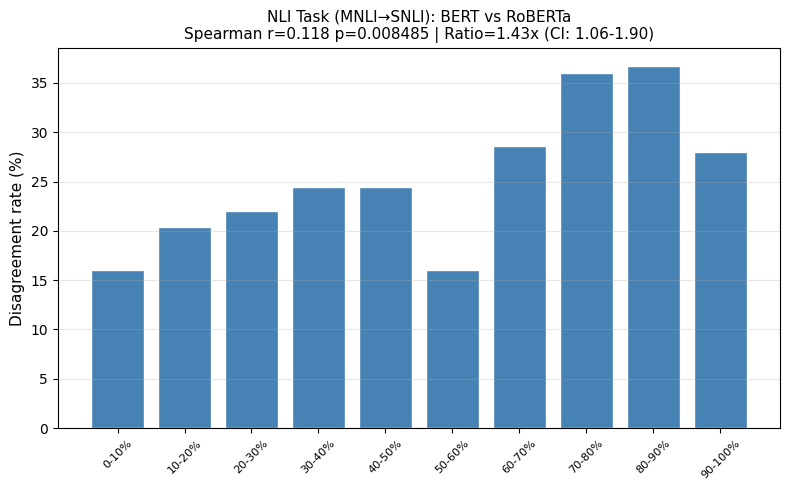


Done.


In [4]:
device = next(model_bert.parameters()).device
print(f"Device: {device}")

def get_boundary_scores_nli(model, tokenizer, sentences):
    model.eval()
    scores = []
    encoded = tokenizer(
        sentences, padding=True, truncation=True,
        max_length=128, return_tensors="pt"
    )
    for i in range(len(encoded['input_ids'])):
        input_ids = encoded['input_ids'][i].unsqueeze(0).to(device)
        attention_mask = encoded['attention_mask'][i].unsqueeze(0).to(device)
        
        if hasattr(model, 'bert'):
            embeddings = model.bert.embeddings.word_embeddings
        elif hasattr(model, 'roberta'):
            embeddings = model.roberta.embeddings.word_embeddings
        
        inputs_embeds = embeddings(input_ids).detach().requires_grad_(True)
        outputs = model(inputs_embeds=inputs_embeds, attention_mask=attention_mask)
        
        # for NLI: margin between top two logits
        logits = outputs.logits[0]
        top2 = logits.topk(2).values
        margin = top2[0] - top2[1]
        margin.backward()
        
        score = inputs_embeds.grad.norm().item()
        scores.append(score)
        
        if (i + 1) % 100 == 0:
            print(f"  Processed {i+1}/{len(encoded['input_ids'])}...")
    
    return np.array(scores)

def get_predictions_nli(model, tokenizer, sentences):
    model.eval()
    predictions = []
    encoded = tokenizer(
        sentences, padding=True, truncation=True,
        max_length=128, return_tensors="pt"
    )
    with torch.no_grad():
        for i in range(len(encoded['input_ids'])):
            input_ids = encoded['input_ids'][i].unsqueeze(0).to(device)
            attention_mask = encoded['attention_mask'][i].unsqueeze(0).to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            pred = outputs.logits.argmax(dim=-1).item()
            predictions.append(pred)
    return np.array(predictions)

def bootstrap_asymmetry(disagreement, divergence, n_bootstrap=200):
    ratios = []
    n = len(disagreement)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        dis = disagreement[idx]
        div = divergence[idx]
        median_div = np.median(div)
        high = div > median_div
        low = div <= median_div
        p_high = dis[high].mean()
        p_low = dis[low].mean()
        ratios.append(p_high / (p_low + 1e-10))
    ratios = np.array(ratios)
    return np.mean(ratios), np.percentile(ratios, 2.5), np.percentile(ratios, 97.5)

print("Functions defined.")

# run the experiment on SNLI
print("\nRunning boundary divergence experiment on SNLI (OOD from MNLI)...")
print("Getting predictions...")
preds_bert = get_predictions_nli(model_bert, tok_bert, snli_sentences)
preds_roberta = get_predictions_nli(model_roberta, tok_roberta, snli_sentences)
disagreement = (preds_bert != preds_roberta).astype(int)

print(f"Disagreement rate: {disagreement.mean()*100:.1f}%")

print("\nComputing boundary scores for BERT...")
scores_bert = get_boundary_scores_nli(model_bert, tok_bert, snli_sentences)
print("Computing boundary scores for RoBERTa...")
scores_roberta = get_boundary_scores_nli(model_roberta, tok_roberta, snli_sentences)
divergence = np.abs(scores_bert - scores_roberta)

# asymmetry test
mean, ci_low, ci_high = bootstrap_asymmetry(disagreement, divergence)
print(f"\nAsymmetry ratio: {mean:.2f}x (95% CI: {ci_low:.2f}-{ci_high:.2f})")
print(f"Significant: {'YES' if ci_low > 1.0 else 'NO'}")

# spearman
r, p = spearmanr(divergence, disagreement)
print(f"Spearman r={r:.3f}, p={p:.6f}")
print(f"Monotonic: {'YES' if p < 0.05 else 'NO'}")

# quantile plot
fig, ax = plt.subplots(figsize=(8, 5))
quantiles = np.percentile(divergence, np.linspace(0, 100, 11))
disagree_rates = []
bin_labels = [f"{i*10}-{(i+1)*10}%" for i in range(10)]

for k in range(10):
    mask = (divergence >= quantiles[k])
    if k < 9:
        mask = mask & (divergence < quantiles[k+1])
    rate = disagreement[mask].mean() if mask.sum() > 0 else 0
    disagree_rates.append(rate * 100)

ax.bar(range(10), disagree_rates, color='steelblue', edgecolor='white')
ax.set_xticks(range(10))
ax.set_xticklabels(bin_labels, rotation=45, fontsize=8)
ax.set_ylabel("Disagreement rate (%)", fontsize=11)
ax.set_title(f"NLI Task (MNLI→SNLI): BERT vs RoBERTa\nSpearman r={r:.3f} p={p:.6f} | Ratio={mean:.2f}x (CI: {ci_low:.2f}-{ci_high:.2f})",
             fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/figure_nli.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDone.")

Error rate by boundary divergence decile
BERT error rate: 31.9%
RoBERTa error rate: 20.0%
Either model wrong: 37.2%
Both models wrong: 14.7%

Spearman correlations (divergence vs error):
  BERT error:    r=0.082, p=0.067590 NO
  RoBERTa error: r=0.010, p=0.831662 NO
  Either error:  r=0.091, p=0.042839 YES


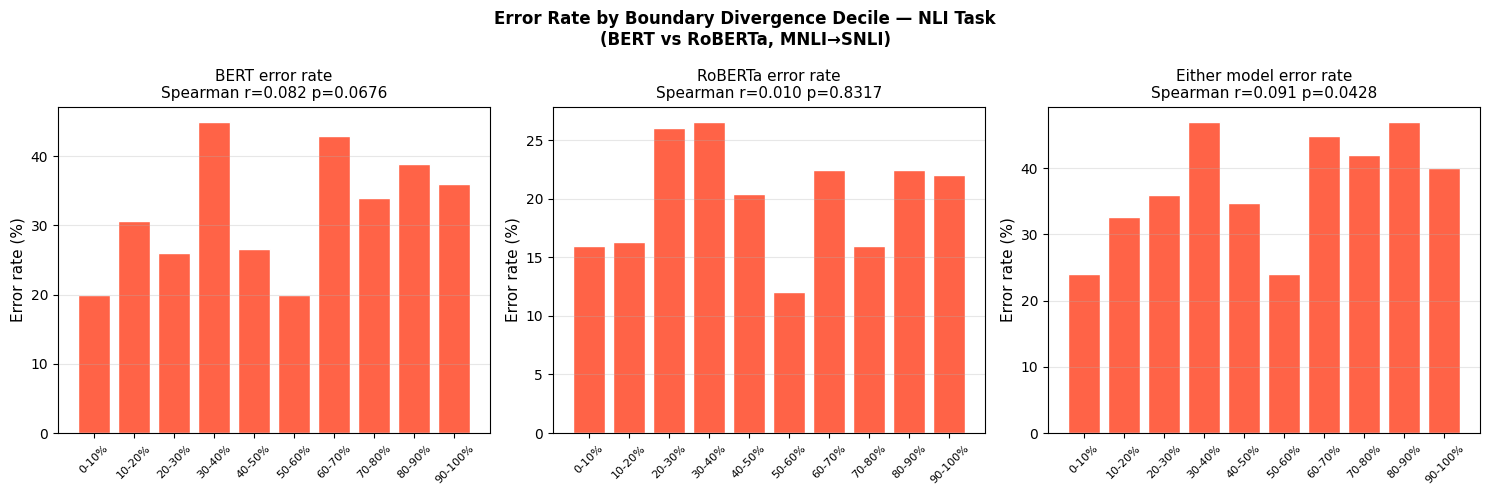


Done.


In [5]:
print("Error rate by boundary divergence decile")
print("=" * 60)

true_labels = np.array(snli_labels[:len(preds_bert)])

# error = either model is wrong
error_bert = (preds_bert != true_labels).astype(int)
error_roberta = (preds_roberta != true_labels).astype(int)
error_either = ((preds_bert != true_labels) | (preds_roberta != true_labels)).astype(int)
error_both = ((preds_bert != true_labels) & (preds_roberta != true_labels)).astype(int)

print(f"BERT error rate: {error_bert.mean()*100:.1f}%")
print(f"RoBERTa error rate: {error_roberta.mean()*100:.1f}%")
print(f"Either model wrong: {error_either.mean()*100:.1f}%")
print(f"Both models wrong: {error_both.mean()*100:.1f}%")

# spearman
r_bert, p_bert = spearmanr(divergence, error_bert)
r_roberta, p_roberta = spearmanr(divergence, error_roberta)
r_either, p_either = spearmanr(divergence, error_either)

print(f"\nSpearman correlations (divergence vs error):")
print(f"  BERT error:    r={r_bert:.3f}, p={p_bert:.6f} {'YES' if p_bert < 0.05 else 'NO'}")
print(f"  RoBERTa error: r={r_roberta:.3f}, p={p_roberta:.6f} {'YES' if p_roberta < 0.05 else 'NO'}")
print(f"  Either error:  r={r_either:.3f}, p={p_either:.6f} {'YES' if p_either < 0.05 else 'NO'}")

# decile plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
error_types = [
    (error_bert, "BERT error rate"),
    (error_roberta, "RoBERTa error rate"),
    (error_either, "Either model error rate")
]

quantiles = np.percentile(divergence, np.linspace(0, 100, 11))
bin_labels = [f"{i*10}-{(i+1)*10}%" for i in range(10)]

for ax, (error, label) in zip(axes, error_types):
    rates = []
    for k in range(10):
        mask = (divergence >= quantiles[k])
        if k < 9:
            mask = mask & (divergence < quantiles[k+1])
        rate = error[mask].mean() * 100 if mask.sum() > 0 else 0
        rates.append(rate)
    
    r, p = spearmanr(divergence, error)
    ax.bar(range(10), rates, color='tomato', edgecolor='white')
    ax.set_xticks(range(10))
    ax.set_xticklabels(bin_labels, rotation=45, fontsize=8)
    ax.set_ylabel("Error rate (%)", fontsize=11)
    ax.set_title(f"{label}\nSpearman r={r:.3f} p={p:.4f}", fontsize=11)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Error Rate by Boundary Divergence Decile — NLI Task\n(BERT vs RoBERTa, MNLI→SNLI)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figure_error_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDone.")

Extracting CLS embeddings...
Embeddings shape: (495, 768)
Running PCA...
Variance explained: 51.8%


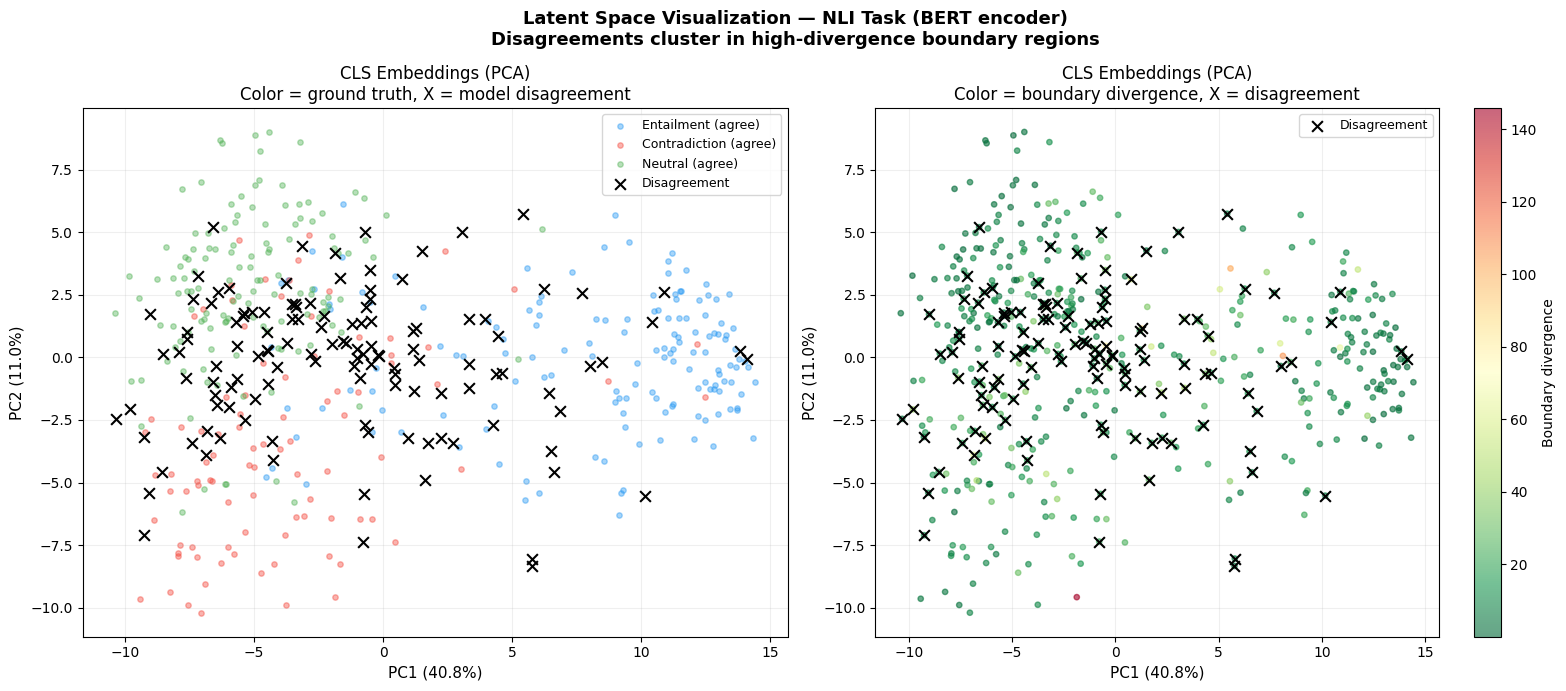

Done.


In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("Extracting CLS embeddings...")

def get_cls_embeddings(model, tokenizer, sentences):
    model.eval()
    embeddings = []
    encoded = tokenizer(
        sentences, padding=True, truncation=True,
        max_length=128, return_tensors="pt"
    )
    with torch.no_grad():
        for i in range(len(encoded['input_ids'])):
            input_ids = encoded['input_ids'][i].unsqueeze(0).to(device)
            attention_mask = encoded['attention_mask'][i].unsqueeze(0).to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True
            )
            cls = outputs.hidden_states[-1][0, 0, :].cpu().numpy()
            embeddings.append(cls)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(encoded['input_ids'])}...")
    return np.array(embeddings)

# get CLS embeddings from BERT
cls_embeddings = get_cls_embeddings(model_bert, tok_bert, snli_sentences)
print(f"Embeddings shape: {cls_embeddings.shape}")

# reduce to 2D with PCA
print("Running PCA...")
pca = PCA(n_components=2)
coords = pca.fit_transform(cls_embeddings)
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# labels and disagreement
true_labels = np.array(snli_labels[:len(preds_bert)])
disagreement = (preds_bert != preds_roberta).astype(int)

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# left plot: color by ground truth, mark disagreements
ax = axes[0]
colors = ['#2196F3', '#F44336', '#4CAF50']  # entailment, contradiction, neutral
label_names = ['Entailment', 'Contradiction', 'Neutral']

for label_idx, (color, name) in enumerate(zip(colors, label_names)):
    mask = (true_labels == label_idx) & (disagreement == 0)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=color, alpha=0.4, s=15, label=f'{name} (agree)')

# overlay disagreement points
disagree_mask = disagreement == 1
ax.scatter(coords[disagree_mask, 0], coords[disagree_mask, 1],
           c='black', marker='x', s=60, linewidths=1.5,
           label='Disagreement', zorder=5)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title("CLS Embeddings (PCA)\nColor = ground truth, X = model disagreement", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# right plot: color by boundary divergence score
ax = axes[1]
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=divergence,
    cmap='RdYlGn_r',
    alpha=0.6,
    s=15
)
plt.colorbar(scatter, ax=ax, label='Boundary divergence')

# overlay disagreement points
ax.scatter(coords[disagree_mask, 0], coords[disagree_mask, 1],
           c='black', marker='x', s=60, linewidths=1.5,
           label='Disagreement', zorder=5)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title("CLS Embeddings (PCA)\nColor = boundary divergence, X = disagreement", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.suptitle("Latent Space Visualization — NLI Task (BERT encoder)\nDisagreements cluster in high-divergence boundary regions",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figure_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done.")